# Stage 03: Python Fundamentals

This notebook demonstrates NumPy elementwise operations, compares a Python loop with vectorized execution, loads and inspects the provided CSV with pandas, calculates descriptive and category-level summaries, saves processed outputs, and creates a basic plot.

**Dataset:** `data/raw/starter_data.csv`

## 0. Reproducible Setup

In [1]:
from pathlib import Path
from timeit import repeat
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_homework_root() -> Path:
    """Locate homework03 from the repository root or a child directory."""
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidate in (base, base / "homework" / "homework03"):
            if (candidate / "data" / "raw" / "starter_data.csv").is_file():
                return candidate
    raise FileNotFoundError("Could not locate homework/homework03/data/raw/starter_data.csv")

HOMEWORK_ROOT = find_homework_root()
if str(HOMEWORK_ROOT) not in sys.path:
    sys.path.insert(0, str(HOMEWORK_ROOT))

from src.utils import get_category_summary, get_summary_stats, require_columns

RAW_DATA_PATH = HOMEWORK_ROOT / "data" / "raw" / "starter_data.csv"
PROCESSED_DIR = HOMEWORK_ROOT / "data" / "processed"
REPORTS_DIR = HOMEWORK_ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Homework root:", HOMEWORK_ROOT)

Python: 3.11.15
NumPy: 2.4.6
pandas: 3.0.5
Homework root: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework03


## 1. NumPy Elementwise Operations

NumPy applies arithmetic to an entire array without an explicit Python loop. The examples below preserve the array shape and return one result per input element.

In [2]:
values = np.arange(1, 6, dtype=float)
squared = values**2
affine_transform = 2 * values + 3
standardized = (values - values.mean()) / values.std()

print("Original:    ", values)
print("Squared:     ", squared)
print("2x + 3:      ", affine_transform)
print("Standardized:", standardized.round(4))

assert np.array_equal(squared, np.array([1.0, 4.0, 9.0, 16.0, 25.0]))
assert np.isclose(standardized.mean(), 0.0)

Original:     [1. 2. 3. 4. 5.]
Squared:      [ 1.  4.  9. 16. 25.]
2x + 3:       [ 5.  7.  9. 11. 13.]
Standardized: [-1.4142 -0.7071  0.      0.7071  1.4142]


## 2. Python Loop vs. Vectorized Execution

Both implementations calculate \(x^2 + 2x + 1\). Timing uses repeated runs and reports the fastest average to reduce one-off system noise. The equality check comes before the speed comparison.

In [3]:
sample_size = 100_000
python_values = list(range(sample_size))
numpy_values = np.arange(sample_size, dtype=float)

def loop_transform(items: list[int]) -> list[int]:
    return [item * item + 2 * item + 1 for item in items]

def vectorized_transform(items: np.ndarray) -> np.ndarray:
    return items * items + 2 * items + 1

loop_result = loop_transform(python_values)
vectorized_result = vectorized_transform(numpy_values)
assert np.array_equal(np.asarray(loop_result), vectorized_result)

loop_seconds = min(repeat(lambda: loop_transform(python_values), repeat=5, number=3)) / 3
vectorized_seconds = min(repeat(lambda: vectorized_transform(numpy_values), repeat=5, number=100)) / 100
speedup = loop_seconds / vectorized_seconds

print(f"Loop average:       {loop_seconds:.6f} seconds")
print(f"Vectorized average: {vectorized_seconds:.6f} seconds")
print(f"Measured speedup:   {speedup:.1f}x")

Loop average:       0.003355 seconds
Vectorized average: 0.000060 seconds
Measured speedup:   55.6x


## 3. Load and Inspect the Dataset

In [4]:
df = pd.read_csv(RAW_DATA_PATH, parse_dates=["date"])
require_columns(df, ["category", "value", "date"])

assert len(df) == 10
assert not df.duplicated().any()
assert df["date"].is_monotonic_increasing

print("Shape:", df.shape)
print("Missing values:")
print(df.isna().sum())
print("\nDataFrame info:")
df.info()
print("\nFirst five rows:")
display(df.head())

Shape: (10, 3)
Missing values:
category    0
value       0
date        0
dtype: int64

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     str           
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 372.0 bytes

First five rows:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


## 4. Summary Statistics and Groupby

In [5]:
summary = get_summary_stats(df)
category_summary = get_category_summary(df)

print("Numeric summary:")
display(summary)
print("Category summary:")
display(category_summary)

assert np.isclose(df["value"].mean(), 17.6)
assert category_summary.loc[category_summary["category"] == "C", "mean"].iloc[0] > 27

Numeric summary:


,feature,count,mean,std,min,25%,50%,75%,max
0,value,10.0,17.6,7.381659,10.0,12.25,14.5,23.25,30.0


Category summary:


,category,count,mean,median,min,max
0,A,4,11.500000,11.5,10,13
1,B,3,15.666667,15.0,14,18
2,C,3,27.666667,28.0,25,30


## 5. Save Processed Outputs

In [6]:
summary_path = PROCESSED_DIR / "summary.csv"
category_summary_path = PROCESSED_DIR / "category_summary.csv"

summary.to_csv(summary_path, index=False)
category_summary.to_csv(category_summary_path, index=False)

print("Saved:", summary_path)
print("Saved:", category_summary_path)
assert summary_path.is_file() and summary_path.stat().st_size > 0
assert category_summary_path.is_file() and category_summary_path.stat().st_size > 0

Saved: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework03/data/processed/summary.csv
Saved: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework03/data/processed/category_summary.csv


## 6. Bonus: Basic Plot

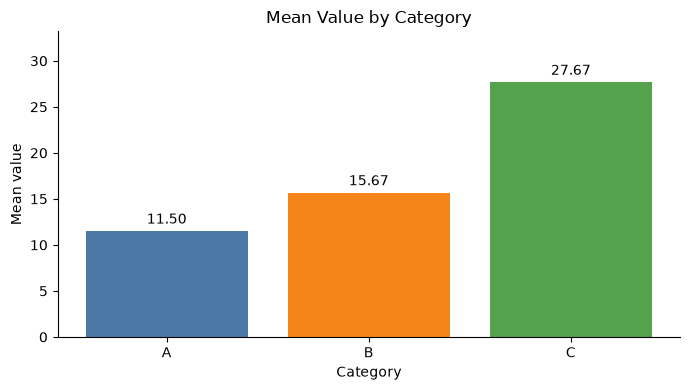

Saved: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework03/reports/category_mean_value.png


In [7]:
plot_path = REPORTS_DIR / "category_mean_value.png"

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(category_summary["category"], category_summary["mean"], color=["#4C78A8", "#F58518", "#54A24B"])
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_title("Mean Value by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Mean value")
ax.set_ylim(0, category_summary["mean"].max() * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)
assert plot_path.is_file() and plot_path.stat().st_size > 0

## 7. Findings, Assumptions, and Limitations

- The dataset contains 10 rows with no missing values or duplicate observations.
- The overall mean of `value` is 17.6. Category C has the highest category mean (about 27.67), while category A has the lowest (11.50).
- Vectorization and the loop return identical values; the timing ratio demonstrates the reduced Python-level overhead of NumPy on this machine. Exact timing will vary across hardware and background load.
- The categories are not evenly sized (A has four rows; B and C each have three), so comparisons should report counts alongside means.
- Ten observations are enough to demonstrate the workflow but not enough for a general population-level conclusion. No causal interpretation is appropriate.

### AI Assistance Disclosure

An AI assistant helped structure the workflow, implement reusable utilities, and review the submission against the Stage 03 rubric. The student is responsible for understanding and validating the code and conclusions.